In [1]:
import numpy as np
import pandas as pd
import json
import csv
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Data Preprocessing
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Feature Selection
from sklearn.linear_model import LassoCV, LogisticRegression, lasso_path
from sklearn.feature_selection import RFECV, RFE
from sklearn.ensemble import RandomForestClassifier

# Oversampling for Imbalanced Data
from imblearn.over_sampling import SMOTE

# Model Training
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from catboost import CatBoostClassifier

# Model Evaluation
import shap
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, auc


# Utility Functions
from collections import Counter

In [2]:
np.random.seed(42)

# Functions

In [3]:
class RandomForestImputer(BaseEstimator, TransformerMixin):
    def __init__(self, n_estimators=100, random_state=42):
        """
        Use Random Forest to impute missing values in a DataFrame.
        """      
        self.n_estimators = n_estimators
        self.random_state = random_state       
        
        # Dictionary to store the trained RandomForest models for each column
        self.imputers_ = {}
        # Stores column order determined during the fit stage
        self.cols_ = []

    def fit(self, X, y=None):
        # Make a copy of the data to avoid modifying the original
        X = X.copy()
        
        # Store all column names to maintain consistency during transformation
        self.cols_ = X.columns
        
        # Identify columns with missing values
        for col in X.columns:
            if X[col].isnull().sum() > 0:
                print(f"Filling missing values in {col} using Random Forest...")
                # Separate known and unknown values
                known = X[X[col].notnull()]
                unknown = X[X[col].isnull()]
                
                # Skip columns with no known or no missing values
                if known.shape[0] == 0 or unknown.shape[0] == 0:
                    continue
                
                # Prepare training data
                X_known = known.drop(columns=[col])
                y_known = known[col]
                
                # Train a Random Forest model to predict missing values
                rf = RandomForestRegressor(n_estimators=self.n_estimators,
                                           random_state=self.random_state)
                rf.fit(X_known, y_known)
                
                # Store the trained model
                self.imputers_[col] = rf
        
        return self

    def transform(self, X, y=None):
        # Make a copy of the data to avoid modifying the original
        X = X.copy()
        
        # Ensure that the column order is consistent with the fit stage
        missing_cols_in_test = set(self.cols_) - set(X.columns)
        if len(missing_cols_in_test) > 0:
            # If some columns from training are missing in the test set, fill them with zeros
            for col in missing_cols_in_test:
                X[col] = 0
        
        # Reorder columns to match the training data
        X = X[self.cols_]
        
        # Use the trained models to impute missing values
        for col, rf_model in self.imputers_.items():
            if X[col].isnull().sum() > 0:
                unknown = X[X[col].isnull()]
                
                # Predict missing values using the trained model
                X.loc[X[col].isnull(), col] = rf_model.predict(unknown.drop(columns=[col]))
        
        return X

In [4]:
def bootstrap_binary_classification_metrics(
    y_true, 
    y_score, 
    threshold=0.5, 
    n_bootstraps=1000, 
    alpha=0.95, 
    random_state=42
):
    """
    Compute AUC, Sensitivity, Specificity, and Accuracy along with their
    (alpha)% confidence intervals using bootstrap sampling.

    """
    rng = np.random.RandomState(random_state)
    
    # Compute metrics on the full data
    auc_full = roc_auc_score(y_true, y_score)
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    sensitivity_full = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity_full = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    accuracy_full = (tp + tn) / (tp + tn + fp + fn)
    
    #  Bootstrap to get confidence intervals
    auc_vals = []
    sens_vals = []
    spec_vals = []
    acc_vals = []
    
    n_samples = len(y_true)
    indices = np.arange(n_samples)
    
    for _ in range(n_bootstraps):
        sample_indices = rng.choice(indices, size=n_samples, replace=True)
        y_true_sample = y_true[sample_indices]
        y_score_sample = y_score[sample_indices]
        
        # Compute metrics on the bootstrap sample
        # AUC
        if len(np.unique(y_true_sample)) == 1:
            continue
        auc_b = roc_auc_score(y_true_sample, y_score_sample)
        auc_vals.append(auc_b)
        
        # Binary prediction based on threshold
        y_pred_sample = (y_score_sample >= threshold).astype(int)
        tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_true_sample, y_pred_sample).ravel()
        
        # Sensitivity
        sens_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0.0
        # Specificity
        spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0.0
        # Accuracy
        acc_b = (tp_b + tn_b) / (tp_b + tn_b + fp_b + fn_b)
        
        sens_vals.append(sens_b)
        spec_vals.append(spec_b)
        acc_vals.append(acc_b)
    
    def ci_bounds(data_list):
        """Return the CI bounds for alpha using sorted data."""
        if len(data_list) == 0:
            # if no valid bootstrap due to all samples having the same class
            return (np.nan, np.nan)
        sorted_vals = np.sort(data_list)
        lower_idx = int(((1 - alpha) / 2) * len(sorted_vals))
        upper_idx = int((1 - (1 - alpha) / 2) * len(sorted_vals)) - 1
        return (sorted_vals[lower_idx], sorted_vals[upper_idx])
    
    auc_ci = ci_bounds(auc_vals)
    sens_ci = ci_bounds(sens_vals)
    spec_ci = ci_bounds(spec_vals)
    acc_ci = ci_bounds(acc_vals)
    
    metrics_dict = {
        "auc": auc_full,
        "auc_ci": auc_ci,
        "sensitivity": sensitivity_full,
        "sensitivity_ci": sens_ci,
        "specificity": specificity_full,
        "specificity_ci": spec_ci,
        "accuracy": accuracy_full,
        "accuracy_ci": acc_ci,
    }
    return metrics_dict

# Train Test Split

In [5]:
# Load the dataset
df = pd.read_csv('stroke.csv')
df.head()

,subject_id,hadm_id,stay_id,gender,ethnicity,insurance_type,married,first_care_unit,age,bmi,...,cbc_hematocrit,cbc_hemoglobin,cbc_mch,cbc_mchc,cbc_mcv,cbc_platelet,cbc_rbc,cbc_rdw,cbc_rdwsd,cbc_wbc
0,10106244,26713233,34344296,female,white,Others,0,CCU,63,NaN,...,40.9,13.6,30.6,33.3,93.0,288.0,4.52,13.2,NaN,20.1
1,10024331,22643604,34032345,male,white,Medicare,1,CCU,73,33.922571,...,29.6,9.8,30.6,32.9,94.0,156.0,3.19,13.4,NaN,10.9
2,10373824,27677881,34440488,female,white,Medicare,1,others,83,18.818924,...,28.7,10.0,31.5,34.7,92.0,342.0,3.16,13.3,NaN,6.1
3,10666266,22293144,31412961,male,others,Medicaid,1,CCU,52,NaN,...,40.0,13.8,28.1,34.9,81.0,269.0,4.93,15.9,NaN,12.0
4,12172562,25942839,33733462,male,white,Medicare,1,CCU,85,30.071168,...,29.2,9.0,23.9,31.0,77.0,373.0,3.78,17.2,NaN,8.7


In [6]:
# Target variable
target_variable = 'postoperative_stroke'

In [7]:
# Drop unnecessary columns
df.drop(columns=['subject_id', 'hadm_id', 'stay_id'], inplace=True)
print("Dataset loaded. Shape after dropping columns:", df.shape)

Dataset loaded. Shape after dropping columns: (7023, 104)


In [8]:
# Drop columns with excessive missing values
threshold = 0.3
missing_ratio = df.isnull().sum() / len(df)
drop_columns = missing_ratio[missing_ratio > threshold].index.tolist()
df.drop(columns=drop_columns, inplace=True)

print(f"Removed {len(drop_columns)} columns due to excessive missing values.")

Removed 28 columns due to excessive missing values.


In [9]:
# Train test split in 7:3 ratio
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

# Data Preprocessing

## Training set

In [10]:
# Categorize Features
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
binary_cols = [col for col in numerical_cols if train_df[col].nunique() == 2]
numerical_cols = list(set(numerical_cols) - set(binary_cols))
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Binary columns: {len(binary_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Numerical columns: 50
Binary columns: 21
Categorical columns: 5


In [11]:
# Fill categorical missing values with "unknown"
train_df[categorical_cols] = train_df[categorical_cols].fillna("unknown")

In [12]:
# One-Hot Encoding for categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_categorical = encoder.fit_transform(train_df[categorical_cols])

# Convert encoded categorical features into a DataFrame
encoded_df = pd.DataFrame(encoded_categorical, columns=encoder.get_feature_names_out(categorical_cols))

# Drop original categorical columns and concatenate encoded features
train_df = train_df.drop(columns=categorical_cols).reset_index(drop=True)
train_df = pd.concat([train_df, encoded_df], axis=1)

print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4916 entries, 0 to 4915
Data columns (total 88 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   married                     4916 non-null   int64  
 1   age                         4916 non-null   int64  
 2   bmi                         4403 non-null   float64
 3   family_history_of_stroke    4916 non-null   int64  
 4   personal_history_of_stroke  4916 non-null   int64  
 5   thrombolysis                4916 non-null   int64  
 6   antiplatelet                4916 non-null   int64  
 7   beta_blockers               4916 non-null   int64  
 8   calcium_channel_blockers    4916 non-null   int64  
 9   acei                        4916 non-null   int64  
 10  antibiotic                  4916 non-null   int64  
 11  arb                         4916 non-null   int64  
 12  nsaid_drug                  4916 non-null   int64  
 13  hypertension                4916 

In [13]:
X_train = train_df.drop(columns=[target_variable])  # Features
y_train = train_df[target_variable]  # Target variable

In [14]:
# Apply Random Forest imputation
imputer = RandomForestImputer(n_estimators=100, random_state=42)
X_train_imputed = imputer.fit_transform(X_train)
# Check if all missing values are filled
print("Missing values after imputation:", X_train_imputed.isnull().sum().sum())

Filling missing values in bmi using Random Forest...
Filling missing values in gcs using Random Forest...
Filling missing values in heart_rate using Random Forest...
Filling missing values in sbp using Random Forest...
Filling missing values in dbp using Random Forest...
Filling missing values in resp_rate using Random Forest...
Filling missing values in temperature using Random Forest...
Filling missing values in spo2 using Random Forest...
Filling missing values in wbc using Random Forest...
Filling missing values in platelets using Random Forest...
Filling missing values in hemoglobin using Random Forest...
Filling missing values in hematocrit using Random Forest...
Filling missing values in creatinine using Random Forest...
Filling missing values in inr using Random Forest...
Filling missing values in pt using Random Forest...
Filling missing values in ptt using Random Forest...
Filling missing values in bun using Random Forest...
Filling missing values in glucose using Random Fore

In [15]:
# Export csv for records
train_imputed_full = pd.concat([X_train_imputed, y_train], axis=1)
encoded_categorical_cols = encoder.get_feature_names_out(categorical_cols)
df_train_numerical = train_imputed_full[numerical_cols + [y_train.name]]
df_train_binary = train_imputed_full[binary_cols + [y_train.name]]
df_train_categorical_encoded = train_imputed_full[list(encoded_categorical_cols) + [y_train.name]]

df_train_numerical.to_csv("X_train_imputed_numerical_cols.csv", index=False)
df_train_binary.to_csv("X_train_imputed_binary_cols.csv", index=False)
df_train_categorical_encoded.to_csv("X_train_imputed_categorical_cols.csv", index=False)

In [16]:
# Apply StandardScaler
scaler = StandardScaler()
X_train_imputed[numerical_cols] = scaler.fit_transform(X_train_imputed[numerical_cols])

## Feature engineering

In [17]:
# Calculate correlation matrix
corr_matrix = X_train_imputed.corr().abs()

# Select the upper triangle of the correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify features with correlation > 0.9
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.9)]
print("Features to drop due to high correlation:", to_drop)

Features to drop due to high correlation: ['sofa_cns', 'hematocrit', 'pt', 'cbc_hemoglobin', 'cbc_wbc', 'gender_male', 'first_care_unit_CVICU', 'treatments_PCI']


In [18]:
# Drop features with high correlation
X_uncorr = X_train_imputed.drop(columns=to_drop)
print(f"Number of features remaining: {X_uncorr.shape[1]}")

Number of features remaining: 79


In [19]:
lasso_cv = LassoCV(cv=10, random_state=42)
lasso_cv.fit(X_uncorr, y_train)

print(f"Best alpha found by LassoCV: {lasso_cv.alpha_}")

Best alpha found by LassoCV: 0.0011908028240717441


In [20]:
# Keep only the features with non-zero coefficients
coef_nonzero = [
    (feature, coef)
    for feature, coef in zip(X_uncorr.columns, lasso_cv.coef_)
    if coef != 0
]
# Sort features by absolute coefficient in descending order
sorted_coefs = sorted(coef_nonzero, key=lambda x: abs(x[1]), reverse=True)

# Keep features with absolute coefficient greater than 0.01
top_coefs = [(feature, coef) for feature, coef in sorted_coefs if abs(coef) > 0.01]
selected_features = [feature for feature, coef in top_coefs]

print("Features with absolute coefficient greater than 0.01:")
for feature, coef in top_coefs:
    print(f"{feature}: {coef}")

Features with absolute coefficient greater than 0.01:
cci: 0.1576837349083273
ckd: -0.1273655796878578
diabetes: -0.08499756895208267
hf: -0.06624113181307142
personal_history_of_stroke: 0.061081604020167844
age: -0.05461086825223131
pvd: 0.04395064664241589
nsaid_drug: -0.02601745315382922
first_care_unit_CCU: -0.01941178348798395
hypertension: 0.01573064759687824
sbp: 0.01201307262978852
hyperlipidemia: 0.01038026685568304


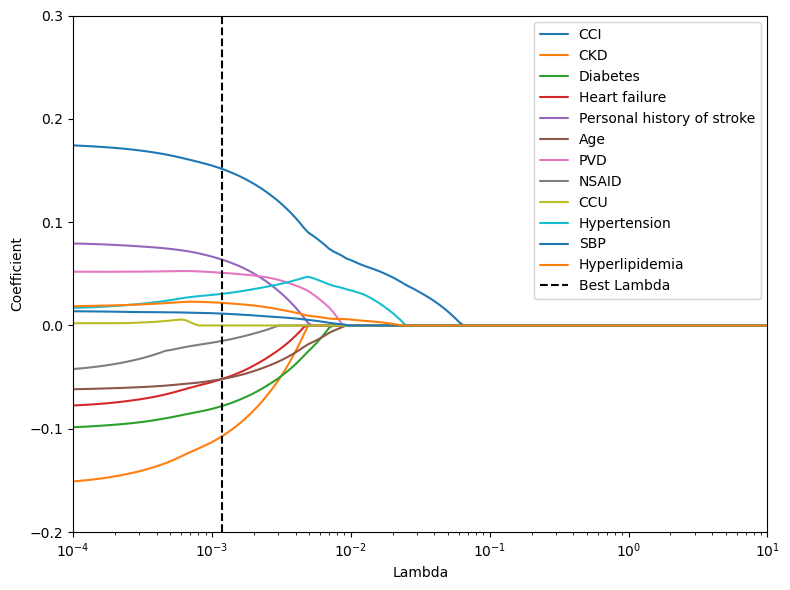

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.linear_model import lasso_path

rename_dict = {
    'cci': 'CCI',
    'ckd': 'CKD',
    'diabetes': 'Diabetes',
    'personal_history_of_stroke': 'Personal history of stroke',
    'hf': 'Heart failure',
    'age': 'Age',
    'pvd': 'PVD',
    'nsaid_drug': 'NSAID',
    'first_care_unit_CCU': 'CCU',
    'hypertension': 'Hypertension',
    'sbp': 'SBP',
    'hyperlipidemia': 'Hyperlipidemia'
}

alphas, coefs, _ = lasso_path(X_uncorr, y_train, eps=1e-3)

plt.figure(figsize=(8, 6))

x_low, x_high = 1e-4, 1e1

for feature in selected_features:
    idx = X_uncorr.columns.get_loc(feature)
    new_label = rename_dict.get(feature, feature)

    x_vals = alphas.copy()
    y_vals = coefs[idx, :].copy()

    if x_vals[0] < x_high:
        x_vals = np.concatenate(([x_high], x_vals))
        y_vals = np.concatenate(([y_vals[0]], y_vals))

    if x_vals[-1] > x_low:
        x_vals = np.concatenate((x_vals, [x_low]))
        y_vals = np.concatenate((y_vals, [y_vals[-1]]))
    
    plt.plot(x_vals, y_vals, label=new_label, 
             solid_joinstyle='round', solid_capstyle='round')

plt.axvline(x=lasso_cv.alpha_, linestyle='--', color='black', label='Best Lambda')

plt.xlabel('Lambda')
plt.ylabel('Coefficient')
plt.xscale('log')
plt.xlim(x_low, x_high)
plt.ylim(-0.2, 0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('lasso_path.tiff', dpi=600, format='tiff')
im = Image.open('lasso_path.tiff')
im.save('lasso_path.tiff', compression='tiff_lzw')
plt.show()


In [35]:
# Filter X_train to keep only selected features
X_feature_selected = X_uncorr[selected_features]

print(X_feature_selected.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4916 entries, 0 to 4915
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cci                         4916 non-null   float64
 1   ckd                         4916 non-null   int64  
 2   diabetes                    4916 non-null   int64  
 3   hf                          4916 non-null   int64  
 4   personal_history_of_stroke  4916 non-null   int64  
 5   age                         4916 non-null   float64
 6   pvd                         4916 non-null   int64  
 7   nsaid_drug                  4916 non-null   int64  
 8   first_care_unit_CCU         4916 non-null   float64
 9   hypertension                4916 non-null   int64  
 10  sbp                         4916 non-null   float64
 11  hyperlipidemia              4916 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 461.0 KB
None


## Testing set

In [36]:
# Categorize Features
numerical_cols = test_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
binary_cols = [col for col in numerical_cols if test_df[col].nunique() == 2]
numerical_cols = list(set(numerical_cols) - set(binary_cols))
categorical_cols = test_df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Binary columns: {len(binary_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Numerical columns: 50
Binary columns: 21
Categorical columns: 5


In [37]:
# Fill categorical missing values with "unknown"
test_df[categorical_cols] = test_df[categorical_cols].fillna("unknown")

In [38]:
# Encoding for test categorical features
encoded_categorical_test = encoder.transform(test_df[categorical_cols])
encoded_df_test = pd.DataFrame(encoded_categorical_test, columns=encoder.get_feature_names_out(categorical_cols))

# Drop original categorical columns and concatenate encoded features
test_df = test_df.drop(columns=categorical_cols).reset_index(drop=True)
test_df = pd.concat([test_df, encoded_df_test], axis=1)

print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2107 entries, 0 to 2106
Data columns (total 88 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   married                     2107 non-null   int64  
 1   age                         2107 non-null   int64  
 2   bmi                         1862 non-null   float64
 3   family_history_of_stroke    2107 non-null   int64  
 4   personal_history_of_stroke  2107 non-null   int64  
 5   thrombolysis                2107 non-null   int64  
 6   antiplatelet                2107 non-null   int64  
 7   beta_blockers               2107 non-null   int64  
 8   calcium_channel_blockers    2107 non-null   int64  
 9   acei                        2107 non-null   int64  
 10  antibiotic                  2107 non-null   int64  
 11  arb                         2107 non-null   int64  
 12  nsaid_drug                  2107 non-null   int64  
 13  hypertension                2107 

In [39]:
X_test = test_df.drop(columns=[target_variable])  # Features
y_test = test_df[target_variable]  # Target variable

In [40]:
# Apply Random Forest imputation from training set
X_test_imputed = imputer.transform(X_test)

# Check if all missing values are filled
print("Missing values after imputation:", X_test_imputed.isnull().sum().sum())

Missing values after imputation: 0


In [41]:
# Export csv for records
test_imputed_full = pd.concat([X_test_imputed, y_test], axis=1)
df_test_numerical = test_imputed_full[numerical_cols + [y_test.name]]
df_test_binary = test_imputed_full[binary_cols + [y_test.name]]
df_test_categorical_encoded = test_imputed_full[list(encoded_categorical_cols) + [y_test.name]]

df_test_numerical.to_csv("X_test_imputed_numerical_cols.csv", index=False)
df_test_binary.to_csv("X_test_imputed_binary_cols.csv", index=False)
df_test_categorical_encoded.to_csv("X_test_imputed_categorical_cols.csv", index=False)

In [42]:
# Apply StandardScaler from training set
X_test_imputed[numerical_cols] = scaler.transform(X_test_imputed[numerical_cols])

In [43]:
# Only keep the features from training set
X_test_final = X_test_imputed[selected_features]
y_test_final = y_test

print(X_test_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2107 entries, 0 to 2106
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cci                         2107 non-null   float64
 1   ckd                         2107 non-null   int64  
 2   diabetes                    2107 non-null   int64  
 3   hf                          2107 non-null   int64  
 4   personal_history_of_stroke  2107 non-null   int64  
 5   age                         2107 non-null   float64
 6   pvd                         2107 non-null   int64  
 7   nsaid_drug                  2107 non-null   int64  
 8   first_care_unit_CCU         2107 non-null   float64
 9   hypertension                2107 non-null   int64  
 10  sbp                         2107 non-null   float64
 11  hyperlipidemia              2107 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 197.7 KB
None


## SMOTE

In [44]:
print(f"Before SMOTE: X shape = {X_feature_selected.shape}, y shape = {y_train.shape}")
print("Class distribution before SMOTE:\n", y_train.value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_final, y_train_final = smote.fit_resample(X_feature_selected, y_train)

print(f"After SMOTE: X shape = {X_train_final.shape}, y shape = {y_train_final.shape}")
print("Class distribution after SMOTE:\n", y_train_final.value_counts())

Before SMOTE: X shape = (4916, 12), y shape = (4916,)
Class distribution before SMOTE:
 postoperative_stroke
0    4528
1     388
Name: count, dtype: int64
After SMOTE: X shape = (9056, 12), y shape = (9056,)
Class distribution after SMOTE:
 postoperative_stroke
0    4528
1    4528
Name: count, dtype: int64


# Training and prediction

## GridSearch (don't use this, use loop search below)

In [34]:
param_grids = {
    "LogisticRegression": {
         'C': [0.1, 0.5, 1.0],
         'penalty': ['l1', 'l2'], 
         'solver': ['saga'],
         'max_iter': [1000, 2000]
    },
    "SVM": {
         'C': [0.5, 1.0, 1.5, 2],
         'gamma': [0.005, 0.008, 0.01],
         'kernel': ['rbf']
    },
    "RandomForest": {
         'n_estimators': [200, 300],
         'max_depth': [3, 4, 5],
         'min_samples_split': [10, 15],
         'min_samples_leaf': [5, 10],
         'max_features': ['sqrt']
    },
    "XGBoost": {
         'learning_rate': [0.005, 0.01],
         'max_depth': [3, 4, 5],
         'n_estimators': [300, 500],
         'subsample': [0.7, 0.8],
         'colsample_bytree': [0.7, 0.8],
         'min_child_weight': [5, 10, 15, 20],
         'reg_alpha': [0.1, 0.5],
         'reg_lambda': [1, 2]
    },
    "AdaBoost": {
         'n_estimators': [200, 250, 300, 400],
         'learning_rate': [0.05, 0.1, 0.3]
    },
    "NaiveBayes": {
         'var_smoothing': [1e-8, 1e-7, 1e-6]
    },
    "KNN": {
         'n_neighbors': [25, 35, 45],
         'weights': ['distance', 'uniform']
    },
    "CatBoost": {
         'depth': [3, 4, 5],
         'learning_rate': [0.005, 0.01],
         'iterations': [800, 1000],
         'l2_leaf_reg': [1, 3, 5],
         'bootstrap_type': ['Bernoulli'],
         'subsample': [0.7, 0.8]
    }
}

In [ ]:
models = {
    "XGBoost": xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ),
    "LogisticRegression": LogisticRegression(
        random_state=42
    ),
   
    "SVM": SVC(
        probability=True,
        random_state=42
    ),
    
    "RandomForest": RandomForestClassifier(
        random_state=42
    ),
    
    
    
    "AdaBoost": AdaBoostClassifier(
        random_state=42,
        estimator=DecisionTreeClassifier(max_depth=2)
    ),
    
    "NaiveBayes": GaussianNB(),
    
    "KNN": KNeighborsClassifier(),
    
    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=False
    )
}

best_models = {}

for model_name, model in models.items():
    print("\n==================================")
    print(f"Grid searching for {model_name} ...")
    print("==================================")
    
    grid = param_grids.get(model_name, {})
    if not grid:
        best_models[model_name] = model
        print(f"No parameters to search for {model_name}.")
        continue

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train_final, y_train_final)
    best_models[model_name] = grid_search.best_estimator_
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")

## Loop Search

In [45]:
xgb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'n_estimators': [100, 200]
}

best_xgb_auc = 0
best_xgb_params = {}
for lr in xgb_param_grid['learning_rate']:
    for md in xgb_param_grid['max_depth']:
        for n in xgb_param_grid['n_estimators']:
            model = xgb.XGBClassifier(learning_rate=lr, max_depth=md, n_estimators=n,
                                      eval_metric='logloss', random_state=42)
            model.fit(X_train_final, y_train_final)
            y_proba = model.predict_proba(X_test_final)[:, 1]
            auc = roc_auc_score(y_test_final, y_proba)
            print(f"XGBoost -> learning_rate: {lr}, max_depth: {md}, n_estimators: {n}, AUC: {auc:.3f}")
            if auc > best_xgb_auc:
                best_xgb_auc = auc
                best_xgb_params = {'learning_rate': lr, 'max_depth': md, 'n_estimators': n}

print("\nBest XGBoost parameters:", best_xgb_params, "with AUC:", best_xgb_auc)

XGBoost -> learning_rate: 0.01, max_depth: 3, n_estimators: 100, AUC: 0.781
XGBoost -> learning_rate: 0.01, max_depth: 3, n_estimators: 200, AUC: 0.802
XGBoost -> learning_rate: 0.01, max_depth: 4, n_estimators: 100, AUC: 0.790
XGBoost -> learning_rate: 0.01, max_depth: 4, n_estimators: 200, AUC: 0.816
XGBoost -> learning_rate: 0.01, max_depth: 5, n_estimators: 100, AUC: 0.816
XGBoost -> learning_rate: 0.01, max_depth: 5, n_estimators: 200, AUC: 0.825
XGBoost -> learning_rate: 0.05, max_depth: 3, n_estimators: 100, AUC: 0.835
XGBoost -> learning_rate: 0.05, max_depth: 3, n_estimators: 200, AUC: 0.841
XGBoost -> learning_rate: 0.05, max_depth: 4, n_estimators: 100, AUC: 0.832
XGBoost -> learning_rate: 0.05, max_depth: 4, n_estimators: 200, AUC: 0.837
XGBoost -> learning_rate: 0.05, max_depth: 5, n_estimators: 100, AUC: 0.836
XGBoost -> learning_rate: 0.05, max_depth: 5, n_estimators: 200, AUC: 0.831
XGBoost -> learning_rate: 0.1, max_depth: 3, n_estimators: 100, AUC: 0.841
XGBoost -> le

In [46]:
lr_param_grid = {
    'C': [0.1, 0.5, 1, 2, 5],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga', 'newton-cg']
}

best_lr_auc = 0
best_lr_params = {}
for C in lr_param_grid['C']:
    for penalty in lr_param_grid['penalty']:
        for solver in lr_param_grid['solver']:
            try:
                model = LogisticRegression(C=C, penalty=penalty, solver=solver,
                                           random_state=42, max_iter=1000)
                model.fit(X_train_final, y_train_final)
                y_proba = model.predict_proba(X_test_final)[:, 1]
                auc = roc_auc_score(y_test_final, y_proba)
                print(f"LogisticRegression -> C: {C}, penalty: {penalty}, solver: {solver}, AUC: {auc:.3f}")
                if auc > best_lr_auc:
                    best_lr_auc = auc
                    best_lr_params = {'C': C, 'penalty': penalty, 'solver': solver}
            except Exception as e:
                continue

print("\nBest LogisticRegression parameters:", best_lr_params, "with AUC:", best_lr_auc)

LogisticRegression -> C: 0.1, penalty: l1, solver: liblinear, AUC: 0.849
LogisticRegression -> C: 0.1, penalty: l1, solver: saga, AUC: 0.849
LogisticRegression -> C: 0.1, penalty: l2, solver: liblinear, AUC: 0.850
LogisticRegression -> C: 0.1, penalty: l2, solver: saga, AUC: 0.850
LogisticRegression -> C: 0.1, penalty: l2, solver: newton-cg, AUC: 0.850
LogisticRegression -> C: 0.5, penalty: l1, solver: liblinear, AUC: 0.848
LogisticRegression -> C: 0.5, penalty: l1, solver: saga, AUC: 0.848
LogisticRegression -> C: 0.5, penalty: l2, solver: liblinear, AUC: 0.849
LogisticRegression -> C: 0.5, penalty: l2, solver: saga, AUC: 0.848
LogisticRegression -> C: 0.5, penalty: l2, solver: newton-cg, AUC: 0.848
LogisticRegression -> C: 1, penalty: l1, solver: liblinear, AUC: 0.848
LogisticRegression -> C: 1, penalty: l1, solver: saga, AUC: 0.848
LogisticRegression -> C: 1, penalty: l2, solver: liblinear, AUC: 0.848
LogisticRegression -> C: 1, penalty: l2, solver: saga, AUC: 0.848
LogisticRegressi

In [47]:
C_values = [0.5, 1, 1.5, 2, 3, 5]
gamma_values = [0.005, 0.01, 0.05, 0.1, 0.3]

best_test_auc = 0
best_params = {}

for C in C_values:
    for gamma in gamma_values:

        model = SVC(C=C, gamma=gamma, kernel='rbf', probability=True, random_state=42)
        model.fit(X_train_final, y_train_final)
        
        y_proba = model.predict_proba(X_test_final)[:, 1]
        test_auc = roc_auc_score(y_test_final, y_proba)
        print(f"C: {C}, gamma: {gamma}, Testing AUC: {test_auc:.3f}")

        if test_auc > best_test_auc:
            best_test_auc = test_auc
            best_svm_params = {'C': C, 'gamma': gamma}

print("\nBest parameters on Testing set:", best_svm_params, "with Testing AUC:", best_test_auc)

C: 0.5, gamma: 0.005, Testing AUC: 0.850
C: 0.5, gamma: 0.01, Testing AUC: 0.855
C: 0.5, gamma: 0.05, Testing AUC: 0.844
C: 0.5, gamma: 0.1, Testing AUC: 0.837
C: 0.5, gamma: 0.3, Testing AUC: 0.821
C: 1, gamma: 0.005, Testing AUC: 0.854
C: 1, gamma: 0.01, Testing AUC: 0.855
C: 1, gamma: 0.05, Testing AUC: 0.838
C: 1, gamma: 0.1, Testing AUC: 0.829
C: 1, gamma: 0.3, Testing AUC: 0.812
C: 1.5, gamma: 0.005, Testing AUC: 0.855
C: 1.5, gamma: 0.01, Testing AUC: 0.854
C: 1.5, gamma: 0.05, Testing AUC: 0.836
C: 1.5, gamma: 0.1, Testing AUC: 0.825
C: 1.5, gamma: 0.3, Testing AUC: 0.805
C: 2, gamma: 0.005, Testing AUC: 0.854
C: 2, gamma: 0.01, Testing AUC: 0.853
C: 2, gamma: 0.05, Testing AUC: 0.834
C: 2, gamma: 0.1, Testing AUC: 0.821
C: 2, gamma: 0.3, Testing AUC: 0.800
C: 3, gamma: 0.005, Testing AUC: 0.854
C: 3, gamma: 0.01, Testing AUC: 0.852
C: 3, gamma: 0.05, Testing AUC: 0.830
C: 3, gamma: 0.1, Testing AUC: 0.818
C: 3, gamma: 0.3, Testing AUC: 0.793
C: 5, gamma: 0.005, Testing AUC: 0.

In [48]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

best_rf_auc = 0
best_rf_params = {}
for n in rf_param_grid['n_estimators']:
    for md in rf_param_grid['max_depth']:
        for mss in rf_param_grid['min_samples_split']:
            model = RandomForestClassifier(n_estimators=n, max_depth=md,
                                           min_samples_split=mss, random_state=42)
            model.fit(X_train_final, y_train_final)
            y_proba = model.predict_proba(X_test_final)[:, 1]
            auc = roc_auc_score(y_test_final, y_proba)
            print(f"RandomForest -> n_estimators: {n}, max_depth: {md}, min_samples_split: {mss}, AUC: {auc:.3f}")
            if auc > best_rf_auc:
                best_rf_auc = auc
                best_rf_params = {'n_estimators': n, 'max_depth': md, 'min_samples_split': mss}

print("\nBest RandomForest parameters:", best_rf_params, "with AUC:", best_rf_auc)

RandomForest -> n_estimators: 100, max_depth: None, min_samples_split: 2, AUC: 0.798
RandomForest -> n_estimators: 100, max_depth: None, min_samples_split: 5, AUC: 0.803
RandomForest -> n_estimators: 100, max_depth: 5, min_samples_split: 2, AUC: 0.791
RandomForest -> n_estimators: 100, max_depth: 5, min_samples_split: 5, AUC: 0.789
RandomForest -> n_estimators: 100, max_depth: 10, min_samples_split: 2, AUC: 0.812
RandomForest -> n_estimators: 100, max_depth: 10, min_samples_split: 5, AUC: 0.812
RandomForest -> n_estimators: 200, max_depth: None, min_samples_split: 2, AUC: 0.794
RandomForest -> n_estimators: 200, max_depth: None, min_samples_split: 5, AUC: 0.801
RandomForest -> n_estimators: 200, max_depth: 5, min_samples_split: 2, AUC: 0.792
RandomForest -> n_estimators: 200, max_depth: 5, min_samples_split: 5, AUC: 0.792
RandomForest -> n_estimators: 200, max_depth: 10, min_samples_split: 2, AUC: 0.812
RandomForest -> n_estimators: 200, max_depth: 10, min_samples_split: 5, AUC: 0.815


In [49]:
ab_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.5, 1, 1.5]
}

best_ab_auc = 0
best_ab_params = {}
for n in ab_param_grid['n_estimators']:
    for lr in ab_param_grid['learning_rate']:
        model = AdaBoostClassifier(n_estimators=n, learning_rate=lr,
                                   random_state=42,
                                   estimator=DecisionTreeClassifier(max_depth=2))
        model.fit(X_train_final, y_train_final)
        y_proba = model.predict_proba(X_test_final)[:, 1]
        auc = roc_auc_score(y_test_final, y_proba)
        print(f"AdaBoost -> n_estimators: {n}, learning_rate: {lr}, AUC: {auc:.3f}")
        if auc > best_ab_auc:
            best_ab_auc = auc
            best_ab_params = {'n_estimators': n, 'learning_rate': lr}

print("\nBest AdaBoost parameters:", best_ab_params, "with AUC:", best_ab_auc)


AdaBoost -> n_estimators: 50, learning_rate: 0.5, AUC: 0.834
AdaBoost -> n_estimators: 50, learning_rate: 1, AUC: 0.836
AdaBoost -> n_estimators: 50, learning_rate: 1.5, AUC: 0.816
AdaBoost -> n_estimators: 100, learning_rate: 0.5, AUC: 0.841
AdaBoost -> n_estimators: 100, learning_rate: 1, AUC: 0.839
AdaBoost -> n_estimators: 100, learning_rate: 1.5, AUC: 0.810
AdaBoost -> n_estimators: 200, learning_rate: 0.5, AUC: 0.845
AdaBoost -> n_estimators: 200, learning_rate: 1, AUC: 0.840
AdaBoost -> n_estimators: 200, learning_rate: 1.5, AUC: 0.813

Best AdaBoost parameters: {'n_estimators': 200, 'learning_rate': 0.5} with AUC: 0.8448113902600751


In [50]:
nb_param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

best_nb_auc = 0
best_nb_params = {}
for vs in nb_param_grid['var_smoothing']:
    model = GaussianNB(var_smoothing=vs)
    model.fit(X_train_final, y_train_final)
    y_proba = model.predict_proba(X_test_final)[:, 1]
    auc = roc_auc_score(y_test_final, y_proba)
    print(f"NaiveBayes -> var_smoothing: {vs}, AUC: {auc:.3f}")
    if auc > best_nb_auc:
        best_nb_auc = auc
        best_nb_params = {'var_smoothing': vs}

print("\nBest NaiveBayes parameters:", best_nb_params, "with AUC:", best_nb_auc)

NaiveBayes -> var_smoothing: 1e-09, AUC: 0.751
NaiveBayes -> var_smoothing: 1e-08, AUC: 0.751
NaiveBayes -> var_smoothing: 1e-07, AUC: 0.751
NaiveBayes -> var_smoothing: 1e-06, AUC: 0.751

Best NaiveBayes parameters: {'var_smoothing': 1e-09} with AUC: 0.7512156487143593


In [51]:
knn_param_grid = {
    'n_neighbors': [5, 10, 15, 20, 25, 30, 50],
    'weights': ['uniform', 'distance']
}

best_knn_auc = 0
best_knn_params = {}
for n in knn_param_grid['n_neighbors']:
    for w in knn_param_grid['weights']:
        model = KNeighborsClassifier(n_neighbors=n, weights=w)
        model.fit(X_train_final, y_train_final)
        y_proba = model.predict_proba(X_test_final)[:, 1]
        auc = roc_auc_score(y_test_final, y_proba)
        print(f"KNN -> n_neighbors: {n}, weights: {w}, AUC: {auc:.3f}")
        if auc > best_knn_auc:
            best_knn_auc = auc
            best_knn_params = {'n_neighbors': n, 'weights': w}

print("\nBest KNN parameters:", best_knn_params, "with AUC:", best_knn_auc)

KNN -> n_neighbors: 5, weights: uniform, AUC: 0.715
KNN -> n_neighbors: 5, weights: distance, AUC: 0.716
KNN -> n_neighbors: 10, weights: uniform, AUC: 0.734
KNN -> n_neighbors: 10, weights: distance, AUC: 0.735
KNN -> n_neighbors: 15, weights: uniform, AUC: 0.742
KNN -> n_neighbors: 15, weights: distance, AUC: 0.743
KNN -> n_neighbors: 20, weights: uniform, AUC: 0.751
KNN -> n_neighbors: 20, weights: distance, AUC: 0.752
KNN -> n_neighbors: 25, weights: uniform, AUC: 0.756
KNN -> n_neighbors: 25, weights: distance, AUC: 0.757
KNN -> n_neighbors: 30, weights: uniform, AUC: 0.757
KNN -> n_neighbors: 30, weights: distance, AUC: 0.759
KNN -> n_neighbors: 50, weights: uniform, AUC: 0.767
KNN -> n_neighbors: 50, weights: distance, AUC: 0.768

Best KNN parameters: {'n_neighbors': 50, 'weights': 'distance'} with AUC: 0.7679569120066798


In [52]:
cb_param_grid = {
    'iterations': [500, 800, 1000],
    'learning_rate': [0.01, 0.03, 0.05],
    'depth': [3, 4, 5]
}

best_cb_auc = 0
best_cb_params = {}
for it in cb_param_grid['iterations']:
    for lr in cb_param_grid['learning_rate']:
        for d in cb_param_grid['depth']:
            model = CatBoostClassifier(iterations=it, learning_rate=lr, depth=d,
                                       random_state=42, verbose=False)
            model.fit(X_train_final, y_train_final)
            y_proba = model.predict_proba(X_test_final)[:, 1]
            auc = roc_auc_score(y_test_final, y_proba)
            print(f"CatBoost -> iterations: {it}, learning_rate: {lr}, depth: {d}, AUC: {auc:.3f}")
            if auc > best_cb_auc:
                best_cb_auc = auc
                best_cb_params = {'iterations': it, 'learning_rate': lr, 'depth': d}

print("\nBest CatBoost parameters:", best_cb_params, "with AUC:", best_cb_auc)

TBB Warning: The number of workers is currently limited to 31. The request for 63 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.



CatBoost -> iterations: 500, learning_rate: 0.01, depth: 3, AUC: 0.831
CatBoost -> iterations: 500, learning_rate: 0.01, depth: 4, AUC: 0.838
CatBoost -> iterations: 500, learning_rate: 0.01, depth: 5, AUC: 0.840
CatBoost -> iterations: 500, learning_rate: 0.03, depth: 3, AUC: 0.846
CatBoost -> iterations: 500, learning_rate: 0.03, depth: 4, AUC: 0.847
CatBoost -> iterations: 500, learning_rate: 0.03, depth: 5, AUC: 0.841
CatBoost -> iterations: 500, learning_rate: 0.05, depth: 3, AUC: 0.845
CatBoost -> iterations: 500, learning_rate: 0.05, depth: 4, AUC: 0.842
CatBoost -> iterations: 500, learning_rate: 0.05, depth: 5, AUC: 0.841
CatBoost -> iterations: 800, learning_rate: 0.01, depth: 3, AUC: 0.842
CatBoost -> iterations: 800, learning_rate: 0.01, depth: 4, AUC: 0.844
CatBoost -> iterations: 800, learning_rate: 0.01, depth: 5, AUC: 0.843
CatBoost -> iterations: 800, learning_rate: 0.03, depth: 3, AUC: 0.847
CatBoost -> iterations: 800, learning_rate: 0.03, depth: 4, AUC: 0.842
CatBoo

In [53]:
models = {
    "XGBoost": xgb.XGBClassifier(
        learning_rate=best_xgb_params['learning_rate'],
        max_depth=best_xgb_params['max_depth'],
        n_estimators=best_xgb_params['n_estimators'],
        eval_metric='logloss',
        random_state=42
    ),
    "LogisticRegression": LogisticRegression(
        C=best_lr_params['C'],
        penalty=best_lr_params['penalty'],
        solver=best_lr_params['solver'],
        random_state=42,
        max_iter=1000
    ),
    "SVM": SVC(
        C=best_svm_params['C'],
        gamma=best_svm_params['gamma'],
        kernel='rbf',
        probability=True,
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=best_rf_params['n_estimators'],
        max_depth=best_rf_params['max_depth'],
        min_samples_split=best_rf_params['min_samples_split'],
        random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=best_ab_params['n_estimators'],
        learning_rate=best_ab_params['learning_rate'],
        random_state=42,
        estimator=DecisionTreeClassifier(max_depth=2)
    ),
    "NaiveBayes": GaussianNB(
        var_smoothing=best_nb_params['var_smoothing']
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=best_knn_params['n_neighbors'],
        weights=best_knn_params['weights']
    ),
    "CatBoost": CatBoostClassifier(
        iterations=best_cb_params['iterations'],
        learning_rate=best_cb_params['learning_rate'],
        depth=best_cb_params['depth'],
        random_state=42,
        verbose=False
    )
}


In [48]:
models_params = {}
for name, model in models.items():
    params = model.get_params()
    for key, value in params.items():
        try:
            json.dumps(value)
        except TypeError:
            params[key] = str(value)
    models_params[name] = params
json_str = json.dumps(models_params, indent=4)

with open("models_params.json", "w") as f:
    f.write(json_str)

In [54]:
# Initialize an empty list to store performance results for each model and dataset
performance_rows = []

for model_name, best_model in models.items():
    print("\n==================================")
    print(f"Training best {model_name}")
    print("==================================")
    
    best_model.fit(X_train_final, y_train_final)
    y_train_score = best_model.predict_proba(X_train_final)[:, 1]
    y_test_score = best_model.predict_proba(X_test_final)[:, 1]
    
    train_metrics = bootstrap_binary_classification_metrics(
        y_train_final, 
        y_train_score, 
        threshold=0.5, 
        n_bootstraps=1000, 
        alpha=0.95,
        random_state=42
    )
    test_metrics = bootstrap_binary_classification_metrics(
        y_test_final, 
        y_test_score, 
        threshold=0.5, 
        n_bootstraps=1000, 
        alpha=0.95,
        random_state=42
    )
    
    # Print performance metrics
    print("[Training Set Performance]")
    print(f"  AUC: {train_metrics['auc']:.3f} (95% CI: {train_metrics['auc_ci'][0]:.3f} - {train_metrics['auc_ci'][1]:.3f})")
    print(f"  Sensitivity: {train_metrics['sensitivity']:.3f} (95% CI: {train_metrics['sensitivity_ci'][0]:.3f} - {train_metrics['sensitivity_ci'][1]:.3f})")
    print(f"  Specificity: {train_metrics['specificity']:.3f} (95% CI: {train_metrics['specificity_ci'][0]:.3f} - {train_metrics['specificity_ci'][1]:.3f})")
    print(f"  Accuracy: {train_metrics['accuracy']:.3f} (95% CI: {train_metrics['accuracy_ci'][0]:.3f} - {train_metrics['accuracy_ci'][1]:.3f})")
    
    print("[Testing Set Performance]")
    print(f"  AUC: {test_metrics['auc']:.3f} (95% CI: {test_metrics['auc_ci'][0]:.3f} - {test_metrics['auc_ci'][1]:.3f})")
    print(f"  Sensitivity: {test_metrics['sensitivity']:.3f} (95% CI: {test_metrics['sensitivity_ci'][0]:.3f} - {test_metrics['sensitivity_ci'][1]:.3f})")
    print(f"  Specificity: {test_metrics['specificity']:.3f} (95% CI: {test_metrics['specificity_ci'][0]:.3f} - {test_metrics['specificity_ci'][1]:.3f})")
    print(f"  Accuracy: {test_metrics['accuracy']:.3f} (95% CI: {test_metrics['accuracy_ci'][0]:.3f} - {test_metrics['accuracy_ci'][1]:.3f})")
    
    # Build dictionary for the training set results
    train_row = {
        'Model': model_name,
        'Dataset': 'Training',
        'AUC': train_metrics['auc'],
        'AUC_ci_lower': train_metrics['auc_ci'][0],
        'AUC_ci_upper': train_metrics['auc_ci'][1],
        'Sensitivity': train_metrics['sensitivity'],
        'Sensitivity_ci_lower': train_metrics['sensitivity_ci'][0],
        'Sensitivity_ci_upper': train_metrics['sensitivity_ci'][1],
        'Specificity': train_metrics['specificity'],
        'Specificity_ci_lower': train_metrics['specificity_ci'][0],
        'Specificity_ci_upper': train_metrics['specificity_ci'][1],
        'Accuracy': train_metrics['accuracy'],
        'Accuracy_ci_lower': train_metrics['accuracy_ci'][0],
        'Accuracy_ci_upper': train_metrics['accuracy_ci'][1]
    }
    
    # Build dictionary for the testing set results
    test_row = {
        'Model': model_name,
        'Dataset': 'Testing',
        'AUC': test_metrics['auc'],
        'AUC_ci_lower': test_metrics['auc_ci'][0],
        'AUC_ci_upper': test_metrics['auc_ci'][1],
        'Sensitivity': test_metrics['sensitivity'],
        'Sensitivity_ci_lower': test_metrics['sensitivity_ci'][0],
        'Sensitivity_ci_upper': test_metrics['sensitivity_ci'][1],
        'Specificity': test_metrics['specificity'],
        'Specificity_ci_lower': test_metrics['specificity_ci'][0],
        'Specificity_ci_upper': test_metrics['specificity_ci'][1],
        'Accuracy': test_metrics['accuracy'],
        'Accuracy_ci_lower': test_metrics['accuracy_ci'][0],
        'Accuracy_ci_upper': test_metrics['accuracy_ci'][1]
    }
    
    # Append the dictionaries to the results list
    performance_rows.extend([train_row, test_row])

# Specify CSV file name
csv_file = "performance_metrics.csv"

# Write the results to the CSV file
with open(csv_file, mode='w', newline='') as file:
    # Assuming all rows have the same keys, we use the keys from one row for the header
    fieldnames = list(performance_rows[0].keys())
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(performance_rows)

print(f"\nPerformance metrics exported to {csv_file}")



Training best XGBoost
[Training Set Performance]
  AUC: 0.965 (95% CI: 0.962 - 0.968)
  Sensitivity: 0.880 (95% CI: 0.871 - 0.889)
  Specificity: 0.900 (95% CI: 0.892 - 0.910)
  Accuracy: 0.890 (95% CI: 0.884 - 0.897)
[Testing Set Performance]
  AUC: 0.841 (95% CI: 0.814 - 0.867)
  Sensitivity: 0.500 (95% CI: 0.425 - 0.573)
  Specificity: 0.908 (95% CI: 0.895 - 0.920)
  Accuracy: 0.875 (95% CI: 0.861 - 0.889)

Training best LogisticRegression
[Training Set Performance]
  AUC: 0.888 (95% CI: 0.882 - 0.895)
  Sensitivity: 0.799 (95% CI: 0.787 - 0.810)
  Specificity: 0.812 (95% CI: 0.801 - 0.823)
  Accuracy: 0.805 (95% CI: 0.797 - 0.814)
[Testing Set Performance]
  AUC: 0.850 (95% CI: 0.822 - 0.875)
  Sensitivity: 0.685 (95% CI: 0.610 - 0.751)
  Specificity: 0.817 (95% CI: 0.801 - 0.835)
  Accuracy: 0.807 (95% CI: 0.790 - 0.823)

Training best SVM
[Training Set Performance]
  AUC: 0.893 (95% CI: 0.886 - 0.899)
  Sensitivity: 0.818 (95% CI: 0.807 - 0.829)
  Specificity: 0.808 (95% CI: 0.7

# SHAP

Using XGBoost for SHAP analysis.


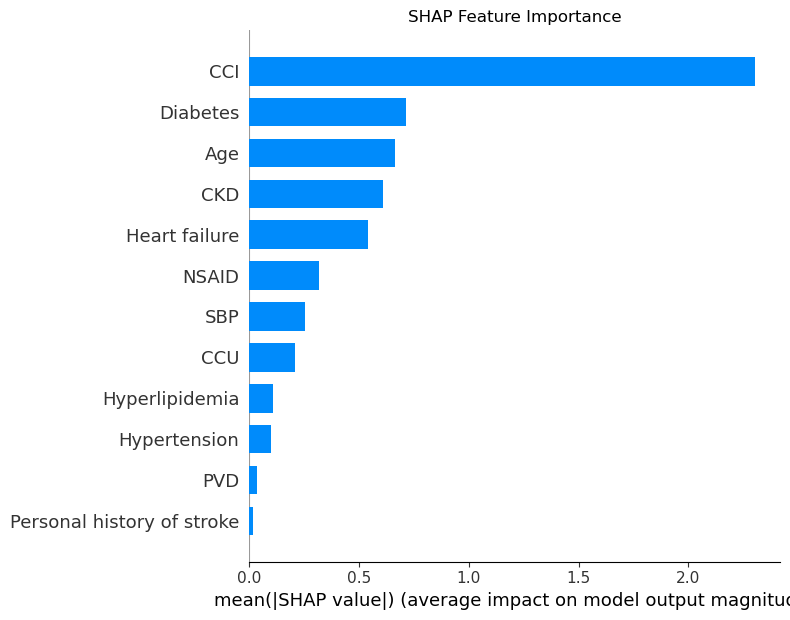

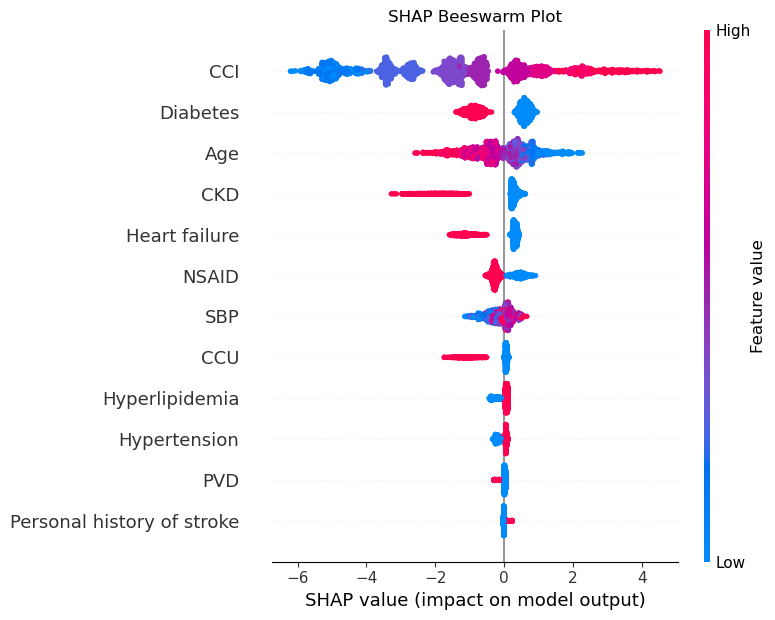

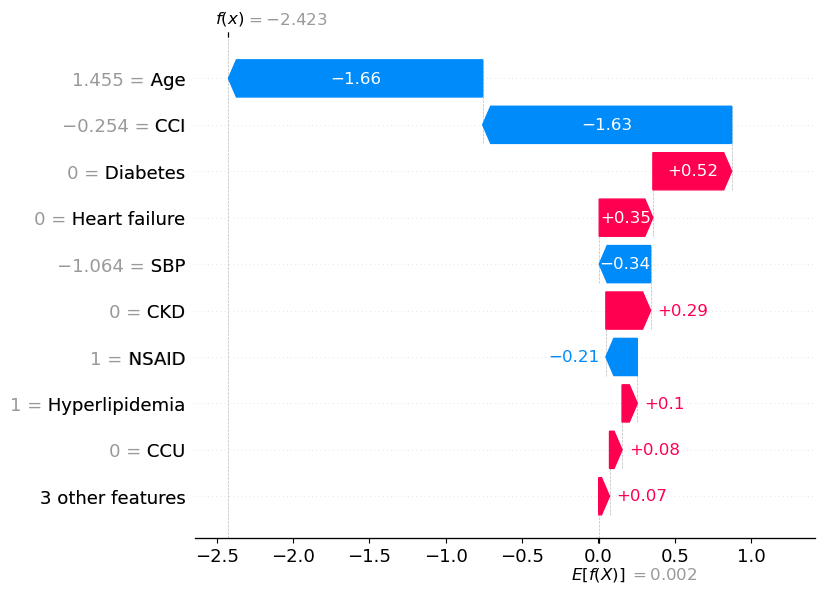

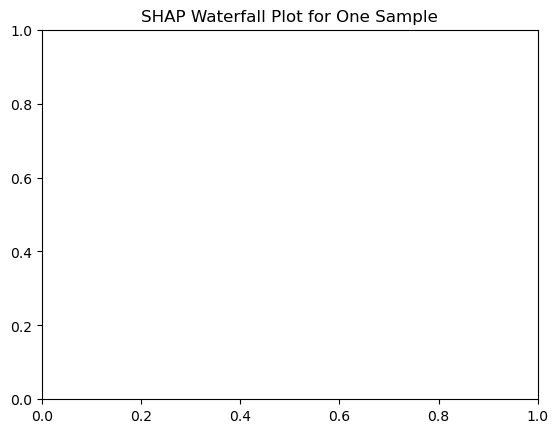

In [55]:
model_to_explain = models["XGBoost"]
print("Using XGBoost for SHAP analysis.")

explainer = shap.TreeExplainer(model_to_explain)
shap_values = explainer.shap_values(X_test_final)

rename_dict = {
    'cci': 'CCI',
    'ckd': 'CKD',
    'diabetes': 'Diabetes',
    'personal_history_of_stroke': 'Personal history of stroke',
    'hf': 'Heart failure',
    'age': 'Age',
    'pvd': 'PVD',
    'nsaid_drug': 'NSAID',
    'first_care_unit_CCU': 'CCU',
    'hypertension': 'Hypertension',
    'sbp': 'SBP',
    'hyperlipidemia': 'Hyperlipidemia'
}
X_test_final_rename = X_test_final.rename(columns=rename_dict)

plt.figure()
shap.summary_plot(shap_values, X_test_final_rename, plot_type="bar", show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.savefig('SHAP Feature Importance.tiff',dpi=600, format='tiff')
im = Image.open('SHAP Feature Importance.tiff')
im.save('SHAP Feature Importance.tiff', compression='tiff_lzw')
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_test_final_rename, show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.savefig('SHAP Beeswarm Plot.tiff',dpi=600, format='tiff')
im = Image.open('SHAP Beeswarm Plot.tiff')
im.save('SHAP Beeswarm Plot.tiff', compression='tiff_lzw')
plt.show()

sample_idx = 0
shap_values_sample = shap_values[sample_idx]

base_value = explainer.expected_value  

shap_expl = shap.Explanation(
    values=shap_values_sample,
    base_values=base_value,
    data=X_test_final_rename.iloc[sample_idx],
    feature_names=X_test_final_rename.columns
)

plt.figure()
shap.plots.waterfall(shap_expl, max_display=10)
plt.title("SHAP Waterfall Plot for One Sample")
plt.show()

## AUC-ROC

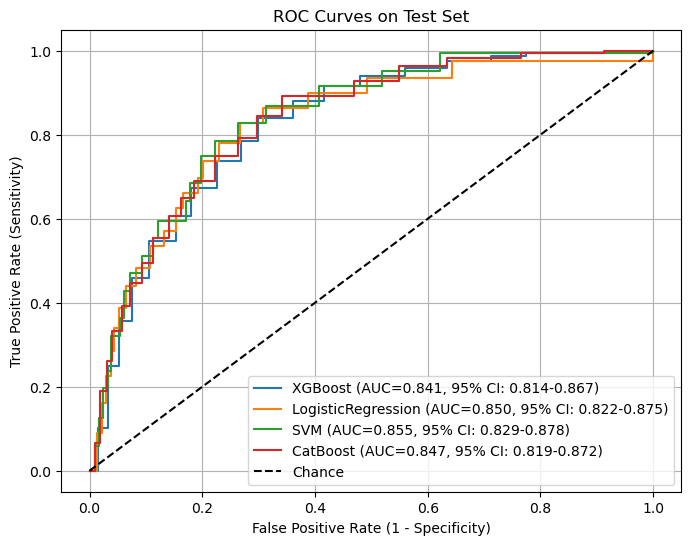

In [56]:
test_metrics = {
    "XGBoost": {"auc_ci": (0.814, 0.867)},
    "LogisticRegression": {"auc_ci": (0.822, 0.875)},
    "SVM": {"auc_ci": (0.829, 0.878)},
    "CatBoost": {"auc_ci": (0.819, 0.872)},
}

selected_models = ["XGBoost", "LogisticRegression", "SVM", "CatBoost"]

plt.figure(figsize=(8, 6))

N_POINTS = 20

for model_name, best_model in models.items():
    if model_name not in selected_models:
        continue
    y_test_score = best_model.predict_proba(X_test_final)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test_final, y_test_score)
    roc_auc = roc_auc_score(y_test_final, y_test_score)
    if model_name in test_metrics and "auc_ci" in test_metrics[model_name]:
        ci_lower, ci_upper = test_metrics[model_name]['auc_ci']
        label_str = (f"{model_name} (AUC={roc_auc:.3f}, "
                     f"95% CI: {ci_lower:.3f}-{ci_upper:.3f})")
    else:
        label_str = f"{model_name} (AUC={roc_auc:.3f})"

    if len(thresholds) > N_POINTS:
        step = len(thresholds) // N_POINTS 
        fpr_coarse = fpr[::step]
        tpr_coarse = tpr[::step]

        if fpr_coarse[-1] != fpr[-1]:
            fpr_coarse = np.append(fpr_coarse, fpr[-1])
            tpr_coarse = np.append(tpr_coarse, tpr[-1])
        plt.step(fpr_coarse, tpr_coarse, where='post', label=label_str)
    else:
        plt.step(fpr, tpr, where='post', label=label_str)

plt.plot([0, 1], [0, 1], 'k--', label='Chance')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves on Test Set')
plt.legend()
plt.grid(True)
plt.savefig('AUC.tiff', dpi=600, format='tiff')
im = Image.open('AUC.tiff')
im.save('AUC.tiff', compression='tiff_lzw')
plt.show()

[0]	validation_0-logloss:0.29826
[1]	validation_0-logloss:0.29285
[2]	validation_0-logloss:0.28825
[3]	validation_0-logloss:0.28433
[4]	validation_0-logloss:0.28114
[5]	validation_0-logloss:0.27834
[6]	validation_0-logloss:0.27586
[7]	validation_0-logloss:0.27373
[8]	validation_0-logloss:0.27189
[9]	validation_0-logloss:0.27029
[10]	validation_0-logloss:0.26899
[11]	validation_0-logloss:0.26776
[12]	validation_0-logloss:0.26678
[13]	validation_0-logloss:0.26592
[14]	validation_0-logloss:0.26506
[15]	validation_0-logloss:0.26454
[16]	validation_0-logloss:0.26433
[17]	validation_0-logloss:0.26397
[18]	validation_0-logloss:0.26354
[19]	validation_0-logloss:0.26326
[20]	validation_0-logloss:0.26296
[21]	validation_0-logloss:0.26283
[22]	validation_0-logloss:0.26220
[23]	validation_0-logloss:0.26206
[24]	validation_0-logloss:0.26199
[25]	validation_0-logloss:0.26192
[26]	validation_0-logloss:0.26169
[27]	validation_0-logloss:0.26158
[28]	validation_0-logloss:0.26159
[29]	validation_0-loglos

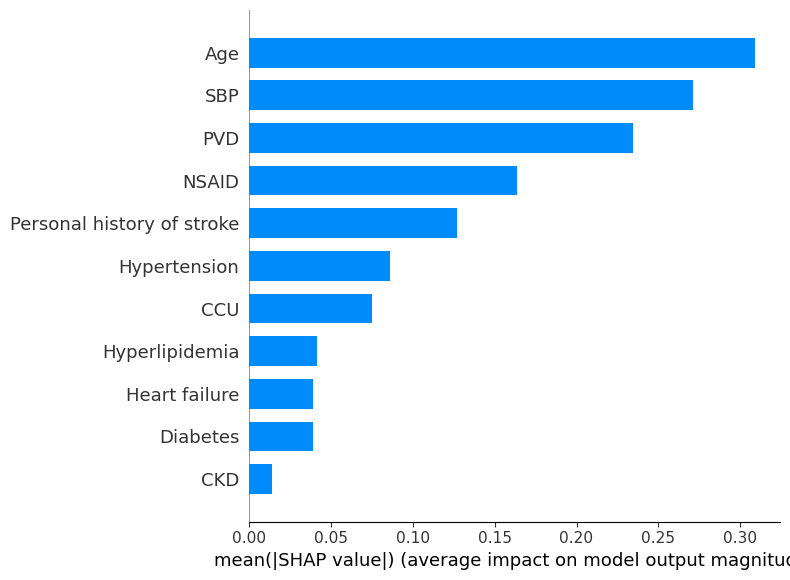

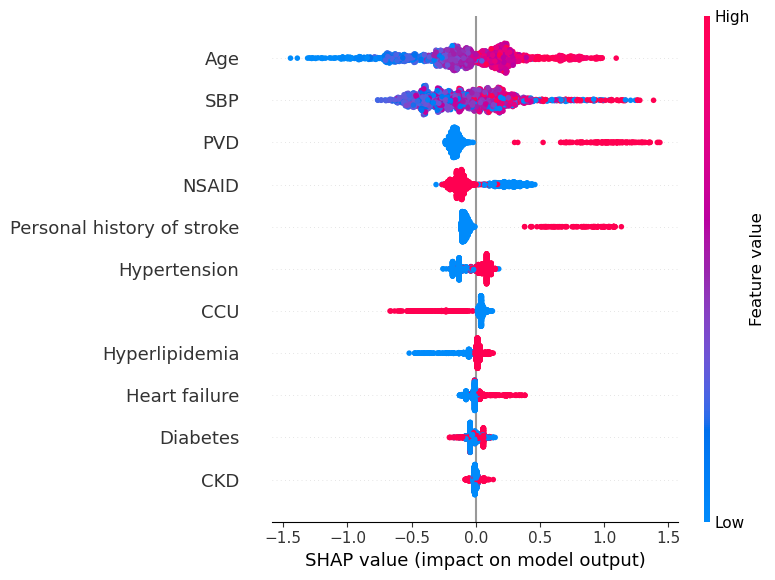

In [57]:
X_train_final_1 = X_feature_selected.copy()
X_test_final_1 = X_test_final.copy()

X_train_no_CCI = X_train_final_1.drop(columns=["cci"])
X_test_no_CCI = X_test_final_1.drop(columns=["cci"])

rename_dict = {
    'cci': 'CCI',
    'ckd': 'CKD',
    'diabetes': 'Diabetes',
    'personal_history_of_stroke': 'Personal history of stroke',
    'hf': 'Heart failure',
    'age': 'Age',
    'pvd': 'PVD',
    'nsaid_drug': 'NSAID',
    'first_care_unit_CCU': 'CCU',
    'hypertension': 'Hypertension',
    'sbp': 'SBP',
    'hyperlipidemia': 'Hyperlipidemia'
}
X_test_no_CCI_rename = X_test_no_CCI.rename(columns=rename_dict)

best_xgb_params = {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

model = xgb.XGBClassifier(
    learning_rate=best_xgb_params['learning_rate'],
    max_depth=best_xgb_params['max_depth'],
    n_estimators=best_xgb_params['n_estimators'],
    eval_metric='logloss',
    random_state=42
)

model.fit(
    X_train_no_CCI, y_train,
    eval_set=[(X_test_no_CCI, y_test_final)],
    verbose=True
)

y_pred_proba = model.predict_proba(X_test_no_CCI)[:, 1]
test_auc = roc_auc_score(y_test_final, y_pred_proba)
print(f"Test AUC: {test_auc:.4f}")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_no_CCI)

shap.summary_plot(shap_values, X_test_no_CCI_rename, plot_type="bar", show=False)
plt.savefig('SHAP_nocci(Bar).tiff', dpi=600, format='tiff')
im = Image.open('SHAP_nocci(Bar).tiff')
im.save('SHAP_nocci(Bar).tiff', compression='tiff_lzw')
plt.show()

shap.summary_plot(shap_values, X_test_no_CCI_rename, show=False)
plt.tight_layout()
plt.savefig('SHAP_nocci.tiff', dpi=600, format='tiff')
im = Image.open('SHAP_nocci.tiff')
im.save('SHAP_nocci.tiff', compression='tiff_lzw')
plt.show()

[0]	validation_0-logloss:0.66563
[1]	validation_0-logloss:0.64375
[2]	validation_0-logloss:0.62537
[3]	validation_0-logloss:0.60758
[4]	validation_0-logloss:0.59272
[5]	validation_0-logloss:0.58161
[6]	validation_0-logloss:0.56992
[7]	validation_0-logloss:0.56101
[8]	validation_0-logloss:0.55464
[9]	validation_0-logloss:0.54597
[10]	validation_0-logloss:0.53975
[11]	validation_0-logloss:0.53511
[12]	validation_0-logloss:0.52846
[13]	validation_0-logloss:0.52196
[14]	validation_0-logloss:0.51834
[15]	validation_0-logloss:0.51412
[16]	validation_0-logloss:0.50960
[17]	validation_0-logloss:0.50503
[18]	validation_0-logloss:0.50145
[19]	validation_0-logloss:0.49769
[20]	validation_0-logloss:0.49526
[21]	validation_0-logloss:0.49264
[22]	validation_0-logloss:0.48988
[23]	validation_0-logloss:0.48744
[24]	validation_0-logloss:0.48517
[25]	validation_0-logloss:0.47960
[26]	validation_0-logloss:0.47656
[27]	validation_0-logloss:0.47561
[28]	validation_0-logloss:0.47315
[29]	validation_0-loglos

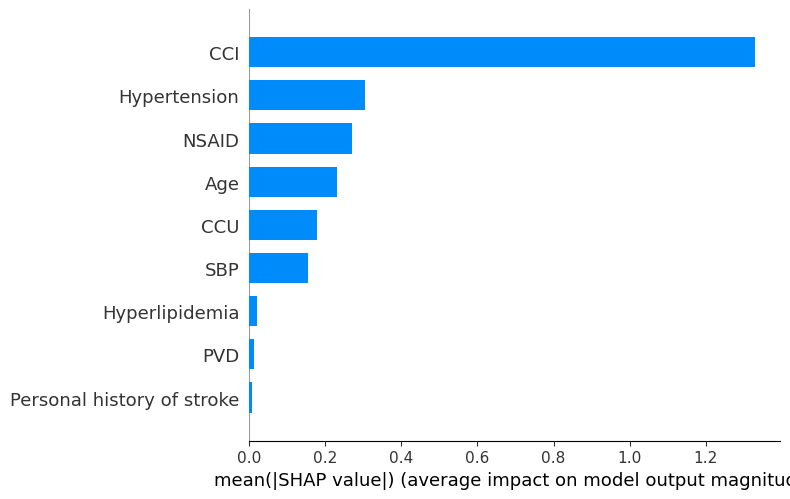

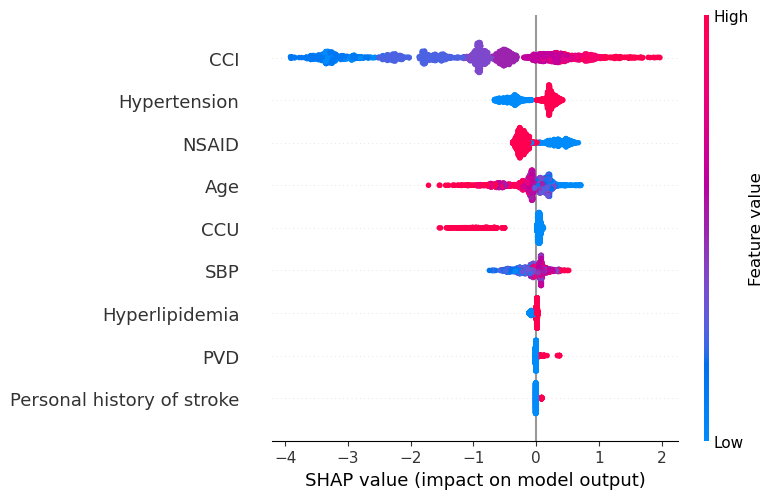

In [66]:
X_train_final_1 = X_train_final.copy()
X_test_final_1 = X_test_final.copy()

X_train_no_CCI = X_train_final_1.drop(columns=["ckd", "diabetes", "hf"])
X_test_no_CCI = X_test_final_1.drop(columns=["ckd", "diabetes", "hf"])

rename_dict = {
    'cci': 'CCI',
    'ckd': 'CKD',
    'diabetes': 'Diabetes',
    'personal_history_of_stroke': 'Personal history of stroke',
    'hf': 'Heart failure',
    'age': 'Age',
    'pvd': 'PVD',
    'nsaid_drug': 'NSAID',
    'first_care_unit_CCU': 'CCU',
    'hypertension': 'Hypertension',
    'sbp': 'SBP',
    'hyperlipidemia': 'Hyperlipidemia'
}
X_test_no_CCI_rename = X_test_no_CCI.rename(columns=rename_dict)

best_xgb_params = {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

model = xgb.XGBClassifier(
    learning_rate=best_xgb_params['learning_rate'],
    max_depth=best_xgb_params['max_depth'],
    n_estimators=best_xgb_params['n_estimators'],
    eval_metric='logloss',
    random_state=42
)

model.fit(
    X_train_no_CCI, y_train_final,
    eval_set=[(X_test_no_CCI, y_test_final)],
    verbose=True
)

y_pred_proba = model.predict_proba(X_test_no_CCI)[:, 1]
test_auc = roc_auc_score(y_test_final, y_pred_proba)
print(f"Test AUC: {test_auc:.4f}")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_no_CCI)

shap.summary_plot(shap_values, X_test_no_CCI_rename, plot_type="bar", show=False)
plt.savefig('SHAP_nocci(Bar).tiff', dpi=600, format='tiff')
plt.show()

shap.summary_plot(shap_values, X_test_no_CCI_rename, show=False)
plt.tight_layout()
plt.savefig('SHAP_nocci.tiff', dpi=600, format='tiff')
plt.show()